In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Base com quali

In [2]:
df_sem_quali = pd.read_csv(r"DATA\oficial.csv")
# df_sem_quali.drop(columns=["posicao_quali_atual", "q1_atual", "q2_atual", "q3_atual", "dif_para_pole_atual"], inplace=True)
df_sem_quali.head()

,temporada_atual,rodada_atual,id_piloto_atual,posicao_quali_atual,q1_atual,q2_atual,q3_atual,target,id_circuito_atual,id_equipe_atual,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
0,2018,1,alonso,11.0,83597.0,83692.0,NaN,5,albert_park,mclaren,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
1,2018,1,bottas,10.0,83686.0,82089.0,NaN,8,albert_park,mercedes,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
2,2018,1,brendon_hartley,16.0,84532.0,NaN,NaN,15,albert_park,toro_rosso,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
3,2018,1,ericsson,17.0,84556.0,NaN,NaN,19,albert_park,sauber,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
4,2018,1,gasly,20.0,85295.0,NaN,NaN,18,albert_park,toro_rosso,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5


In [32]:
df_sem_quali["target"] = (df_sem_quali["target"] <= 3).astype(int)

In [33]:
df_sem_quali["posicao_equipe_anterior"] = pd.to_numeric(df_sem_quali["posicao_equipe_anterior"], errors="coerce")

df_sem_quali.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temporada_atual               3590 non-null   int64  
 1   rodada_atual                  3590 non-null   int64  
 2   id_piloto_atual               3590 non-null   object 
 3   posicao_quali_atual           3583 non-null   float64
 4   q1_atual                      3519 non-null   float64
 5   q2_atual                      2627 non-null   float64
 6   q3_atual                      1737 non-null   float64
 7   target                        3590 non-null   int32  
 8   id_circuito_atual             3590 non-null   object 
 9   id_equipe_atual               3590 non-null   object 
 10  grid_anterior                 3381 non-null   float64
 11  posicao_ultima_corrida        3381 non-null   float64
 12  status                        3381 non-null   object 
 13  pon

In [34]:
df_sem_quali.describe()

,temporada_atual,rodada_atual,posicao_quali_atual,q1_atual,q2_atual,q3_atual,target,grid_anterior,posicao_ultima_corrida,pontos_anterior_individual,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
count,3590.000000,3590.000000,3583.000000,3519.000000,2627.000000,1737.000000,3590.000000,3381.000000,3381.000000,3381.000000,...,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3590.000000,3590.000000,3590.000000,3590.000000,3590.000000
mean,2021.805850,11.122563,10.506001,85376.666098,84565.365817,84263.411629,0.149582,10.264123,10.508429,5.074091,...,10.512197,10.511137,1.144624,-0.240200,0.001060,23.397187,35.273671,53.775253,0.033426,5.389861
std,2.415682,6.456837,5.772768,12093.848751,11619.245389,11737.978265,0.356711,5.818943,5.786564,7.216828,...,4.662668,4.429625,1.284052,3.336187,1.471952,4.909411,9.075277,16.541314,0.179772,16.324197
min,2018.000000,1.000000,1.000000,63807.000000,63015.000000,62939.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,-18.000000,-6.800000,9.500000,15.210000,7.110000,0.000000,0.000000
25%,2020.000000,5.000000,6.000000,76506.000000,75916.500000,75406.000000,0.000000,5.000000,5.000000,0.000000,...,7.000000,7.000000,0.000000,-2.000000,-0.730000,20.120000,28.970000,42.320000,0.000000,0.000000
50%,2022.000000,11.000000,11.000000,84464.000000,84054.000000,84084.000000,0.000000,10.000000,11.000000,0.000000,...,11.000000,11.200000,1.000000,0.000000,0.000000,23.200000,35.230000,54.720000,0.000000,0.000000
75%,2024.000000,17.000000,15.000000,92561.000000,91702.500000,91340.000000,0.000000,15.000000,16.000000,9.000000,...,14.330000,14.000000,2.000000,2.000000,0.740000,27.130000,42.030000,63.900000,0.000000,0.500000
max,2026.000000,24.000000,22.000000,141611.000000,126688.000000,124933.000000,1.000000,22.000000,22.000000,26.000000,...,22.000000,22.000000,8.000000,14.000000,5.530000,36.570000,54.530000,96.440000,1.000000,98.000000


In [35]:
df_sem_quali.drop(columns=["id_piloto_atual"], inplace=True)

In [36]:
X = df_sem_quali.drop(columns=['target'])
y = df_sem_quali['target']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [39]:
onehotencoder = ColumnTransformer(transformers=[
    ('OneHot', OneHotEncoder(handle_unknown='ignore'), ['id_circuito_atual', 'id_equipe_atual', 'status'])
], remainder='passthrough')

In [40]:
X_train_transformed = onehotencoder.fit_transform(X_train)
X_test_transformed = onehotencoder.transform(X_test)

In [41]:
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "scale_pos_weight": [1, 3, 5.35, 7, 10]
}

xgb_model = xgb.XGBClassifier(random_state=42)

grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="accuracy", n_iter=100, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train_transformed, y_train)

best_xgb = grid_search.best_estimator_

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor acurácia:", grid_search.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Melhores parâmetros: {'subsample': 1.0, 'scale_pos_weight': 3, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Melhor acurácia: 0.9042574041811846


In [42]:
y_pred = best_xgb.predict(X_test_transformed)

test_accuracy = accuracy_score(y_test, y_pred)
print("Acurácia: ", test_accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia:  0.8997214484679665

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       605
           1       0.66      0.73      0.70       113

    accuracy                           0.90       718
   macro avg       0.81      0.83      0.82       718
weighted avg       0.90      0.90      0.90       718


Matriz de confusão:
 [[563  42]
 [ 30  83]]


Entendendo as features utilizadas

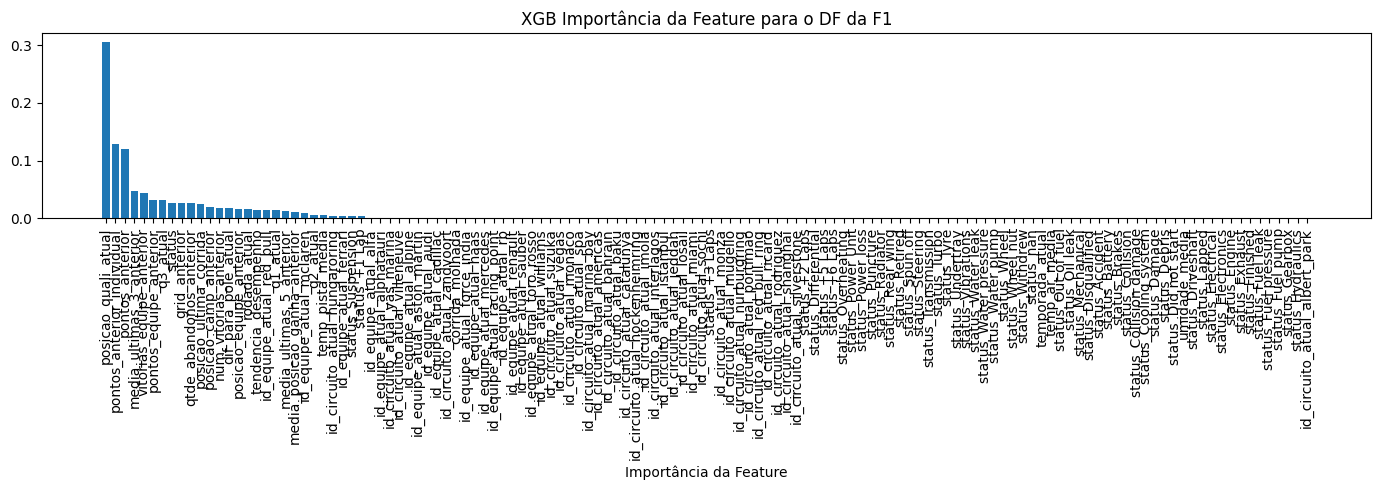

In [43]:
colunas_ohe = onehotencoder.named_transformers_['OneHot'].get_feature_names_out(['id_circuito_atual', 'id_equipe_atual', 'status'])
colunas_resto = [c for c in X.columns if c not in ['id_circuito_atual', 'id_equipe_atual']]
feature_names = list(colunas_ohe) + list(colunas_resto)

feature_importances = best_xgb.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(14, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Importância da Feature")
plt.title("XGB Importância da Feature para o DF da F1")
plt.tight_layout()
plt.show()

In [44]:
import joblib

joblib.dump(best_xgb, r"modelos\modelo_com_quali.pkl")
joblib.dump(onehotencoder, r"modelos\encoder_com_quali.pkl")

['modelos\\encoder_com_quali.pkl']

# Testes

In [45]:
df = pd.read_csv(r"DATA\analise.csv")

In [46]:
df.head()

,temporada_atual,rodada_atual,id_piloto_atual,id_circuito_atual,id_equipe_atual,grid_anterior,posicao_ultima_corrida,pontos_anterior_individual,media_posicao_ganha_anterior,status,...,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva,posicao_quali_atual,q1_atual,q2_atual,q3_atual,dif_para_pole_atual
0,2026,7,antonelli,catalunya,mercedes,1,1,25,0.33,Finished,...,30.27,37.2,36.33,0,0.0,3,75977,75295.0,74998.0,319.0
1,2026,7,hamilton,catalunya,ferrari,3,2,18,1.33,Finished,...,30.27,37.2,36.33,0,0.0,2,75625,75418.0,74743.0,64.0
2,2026,7,gasly,catalunya,alpine,9,3,15,0.00,Finished,...,30.27,37.2,36.33,0,0.0,14,76599,76261.0,76261.0,1582.0
3,2026,7,hadjar,catalunya,red_bull,5,4,12,1.00,Finished,...,30.27,37.2,36.33,0,0.0,6,76427,75754.0,75077.0,398.0
4,2026,7,piastri,catalunya,mclaren,7,5,10,-0.33,Finished,...,30.27,37.2,36.33,0,0.0,7,76138,75518.0,75090.0,411.0


In [47]:
import joblib
import pandas as pd

modelo = joblib.load(r"modelos\modelo_com_quali.pkl")
encoder = joblib.load(r"modelos\encoder_com_quali.pkl")

df = pd.read_csv(r"DATA\analise.csv")

X_train_transformed = encoder.transform(df)
predicoes = modelo.predict_proba(X_train_transformed)

print(predicoes)


[[0.31895137 0.68104863]
 [0.31307447 0.68692553]
 [0.8254544  0.1745456 ]
 [0.8087613  0.19123872]
 [0.57878226 0.42121774]
 [0.84600186 0.15399815]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.30937153 0.69062847]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.6774763  0.32252368]
 [0.8472507  0.15274929]
 [0.52738214 0.47261786]
 [0.8472507  0.15274929]
 [0.8472507  0.15274929]
 [0.6386099  0.36139014]]


In [48]:
print(encoder.feature_names_in_)

['temporada_atual' 'rodada_atual' 'posicao_quali_atual' 'q1_atual'
 'q2_atual' 'q3_atual' 'id_circuito_atual' 'id_equipe_atual'
 'grid_anterior' 'posicao_ultima_corrida' 'status'
 'pontos_anterior_individual' 'posicao_equipe_anterior'
 'pontos_equipe_anterior' 'vitorias_equipe_anterior' 'dif_para_pole_atual'
 'pontos_anterior' 'posicao_camp_anterior' 'num_vitorias_anterior'
 'media_ultimas_3_anterior' 'media_ultimas_5_anterior'
 'qtde_abandonos_anterior' 'media_posicao_ganha_anterior'
 'tendencia_desempenho' 'temp_ar_media' 'temp_pista_media' 'umidade_media'
 'corrida_molhada' 'perc_voltas_chuva']


In [53]:
probs = modelo.predict_proba(X_train_transformed)[:, 1]

df_result = df.copy()
df_result['prob_podio'] = probs
df_result['predicao'] = modelo.predict(X_train_transformed)

predict = df_result[['id_piloto_atual', 'prob_podio', 'predicao']].sort_values('prob_podio', ascending=False)
print(predict)

   id_piloto_atual  prob_podio  predicao
11         russell    0.690628         1
1         hamilton    0.686926         1
0        antonelli    0.681049         1
18          norris    0.472618         0
4          piastri    0.421218         0
21  max_verstappen    0.361390         0
16         leclerc    0.322524         0
3           hadjar    0.191239         0
2            gasly    0.174546         0
5           lawson    0.153998         0
8             ocon    0.152749         0
9           alonso    0.152749         0
10       bortoleto    0.152749         0
7            albon    0.152749         0
13       colapinto    0.152749         0
14           perez    0.152749         0
15           sainz    0.152749         0
6   arvid_lindblad    0.152749         0
17          stroll    0.152749         0
19         bearman    0.152749         0
20          bottas    0.152749         0
12      hulkenberg    0.152749         0


In [54]:
json_string = predict.to_json(orient='records', indent=4)
print(json_string)

[
    {
        "id_piloto_atual":"russell",
        "prob_podio":0.690628469,
        "predicao":1
    },
    {
        "id_piloto_atual":"hamilton",
        "prob_podio":0.6869255304,
        "predicao":1
    },
    {
        "id_piloto_atual":"antonelli",
        "prob_podio":0.6810486317,
        "predicao":1
    },
    {
        "id_piloto_atual":"norris",
        "prob_podio":0.4726178646,
        "predicao":0
    },
    {
        "id_piloto_atual":"piastri",
        "prob_podio":0.4212177396,
        "predicao":0
    },
    {
        "id_piloto_atual":"max_verstappen",
        "prob_podio":0.3613901436,
        "predicao":0
    },
    {
        "id_piloto_atual":"leclerc",
        "prob_podio":0.3225236833,
        "predicao":0
    },
    {
        "id_piloto_atual":"hadjar",
        "prob_podio":0.1912387162,
        "predicao":0
    },
    {
        "id_piloto_atual":"gasly",
        "prob_podio":0.174545601,
        "predicao":0
    },
    {
        "id_piloto_atual":"lawson"

In [5]:
import os
import streamlit as st
from google.cloud import storage
from google.oauth2 import service_account
import pickle


def get_storage_client():
    if os.getenv("GOOGLE_APPLICATION_CREDENTIALS"):
        return storage.Client()
    
    credentials = service_account.Credentials.from_service_account_info(st.secrets["gcp_service_account"])
    return storage.Client(
        credentials=credentials,
        project=credentials.project_id
    )

def salva_gcs(caminho):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "clever-axe-457319-g8-833d2d4ab67f.json"

    client = get_storage_client()
    bucket = client.bucket("f1-dashboard-pilotos")
    blob = bucket.blob(caminho)

    blob.upload_from_filename(caminho)

modelos = ["modelos/modelo_com_quali.pkl", "modelos/encoder_com_quali.pkl"]
for i in modelos:
    salva_gcs(i)